In [1]:

import os
from dotenv import load_dotenv
load_dotenv()
from typing import List, Dict, Any, Optional,TypedDict,Any
from langgraph.graph import StateGraph, START, END

from langchain_groq import ChatGroq


llm=ChatGroq(model="llama-3.3-70b-versatile")
from langchain_core.messages import HumanMessage


In [4]:
class GraphState(TypedDict):
    question: str
    answer: str

def generate_answer(state: GraphState):
    response = llm.invoke([HumanMessage(content=state["question"])])
    print("genrate state", state)
    return {"answer": response.content}

def format_answer(state: GraphState):
    formatted = f"Professional Response:\n\n{state['answer']}"
    print("answer state", state)
    return {"answer": formatted}

builder = StateGraph(GraphState)

builder.add_node("generate", generate_answer)
builder.add_node("format", format_answer)

builder.set_entry_point("generate")
builder.add_edge("generate", "format")
builder.set_finish_point("format")

graph = builder.compile()

if __name__ == "__main__":
    result = graph.invoke({"question": "Explain AI briefly."})
    print(result["answer"])

genrate state {'question': 'Explain AI briefly.'}
answer state {'question': 'Explain AI briefly.', 'answer': 'Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n* Learning\n* Problem-solving\n* Reasoning\n* Perception\n* Decision-making\n\nAI systems use algorithms, data, and machine learning to enable machines to think and act like humans. The goal of AI is to create systems that can automate tasks, make predictions, and improve decision-making, often with the ability to learn and adapt over time.'}
Professional Response:

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:

* Learning
* Problem-solving
* Reasoning
* Perception
* Decision-making

AI systems use algorithms, data, and machine learning to enable machines to think and act like humans. The goal of AI is to create systems that 

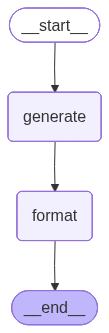

In [5]:
graph